# Design Freeze v3——正式取代 `v1`/`v2`,接上官方 `Stage 3/4` 真實結果

**`v1`/`v2` 都已廢棄**:兩者都是在不知情的狀況下,跟 `repo` 裡已經
存在的官方 `Stage 2/3/4`(`VL-15`/`VL-16`)平行、獨立重建需求做出
來的,精確度不如官方版本(`v1`/`v2` 的 `1F` 柱軸力是反推估計值
`308.85kN`,官方值是用真實從屬寬度算出的 `171.52kN`)。`v3` 直接
重新執行官方 `stage3_load_combinations_demand_extraction.ipynb`
(`VL-16`)跟 `stage4_rc_design_loop.ipynb`,組裝成真正該凍結的版本。

In [1]:

import json, os
try:
    import openseespy.opensees as ops
except ImportError:
    import sys
    !{sys.executable} -m pip install -q "numpy<2.5" openseespy
    import openseespy.opensees as ops
try:
    from rc_design import design_column_PM, design_rebar, design_stirrups
except ImportError:
    import sys
    !wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
    from rc_design import design_column_PM, design_rebar, design_stirrups

print("環境準備完成")


環境準備完成


## 重新執行官方 `Stage 3`(載重組合 `+` `demand extraction`)跟 `Stage 4`(`RC` 設計 `Loop`)

直接抓取 `GitHub` 上的官方檔案內容執行,不是手動謄寫數字。

In [2]:

import urllib.request

for fname in ['stage3_load_combinations_demand_extraction.ipynb', 'stage4_rc_design_loop.ipynb']:
    if not os.path.exists(fname):
        url = f'https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/notebooks/{fname}'
        urllib.request.urlretrieve(url, fname)
        print(f"下載完成: {fname}")

import nbformat
nb3 = nbformat.read('stage3_load_combinations_demand_extraction.ipynb', as_version=4)
nb4 = nbformat.read('stage4_rc_design_loop.ipynb', as_version=4)
print(f"Stage3: {len(nb3.cells)}格, Stage4: {len(nb4.cells)}格")


Stage3: 28格, Stage4: 15格


柱 40x40cm  0.7Ig=0.001493 m^4
梁 30x50cm  0.35Ig=0.001094 m^4
從屬寬度 = 4.5 m
D_area(樓板自重+粉刷) = 460 kg/m^2
D_udl(樓板+梁自重) = 23.830 kN/m
L_udl = 13.239 kN/m
D+L = 37.069 kN/m
柱自重(沿柱軸向) = 3.766 kN/m

[對照] Stage 2 用的暫用值 w=49.2 kN/m, 這一課重新算出 D+L=37.07 kN/m, 差了 24.7%
[開放項目] 這個落差沒有回頭改Stage2用掉的49.2(那一課的重點是
驗模型/驗solver, 不是驗荷重), 但這裡如實記錄, 不掩蓋——Stage2的
49.2是從更早的Case-03.6概估值反推, 可能含牆重或不同活載重假設,
沒有繼續往回查證到底(Case-03.6本身也沒有詳列每一項怎麼來的),
這一課的37.07才是第一次有完整、可追溯依據的算法。
C1: 1.4D+1.7L          D係數=1.4  L係數=1.7  Ex係數=0.0
C2: 1.05D+1.403Ex      D係數=1.05  L係數=0.0  Ex係數=1.403
C3: 1.05D-1.403Ex      D係數=1.05  L係數=0.0  Ex係數=-1.403
C4: 0.9D+1.40Ex        D係數=0.9  L係數=0.0  Ex係數=1.4
C5: 0.9D-1.40Ex        D係數=0.9  L係數=0.0  Ex係數=-1.4
C6: 0.9D               D係數=0.9  L係數=0.0  Ex係數=0.0
共 6 組合 x 6構件(+2個中跨查詢點) = 48 筆記錄
構件        量          govern值     combo
col1F_L   N_i        372.115        C1
col1F_L   V_i         27.792        C3
col1F_L   M_i        -56.432        C3
col1F_L   N_j       -353.663        C1
col1F_L   V_j        

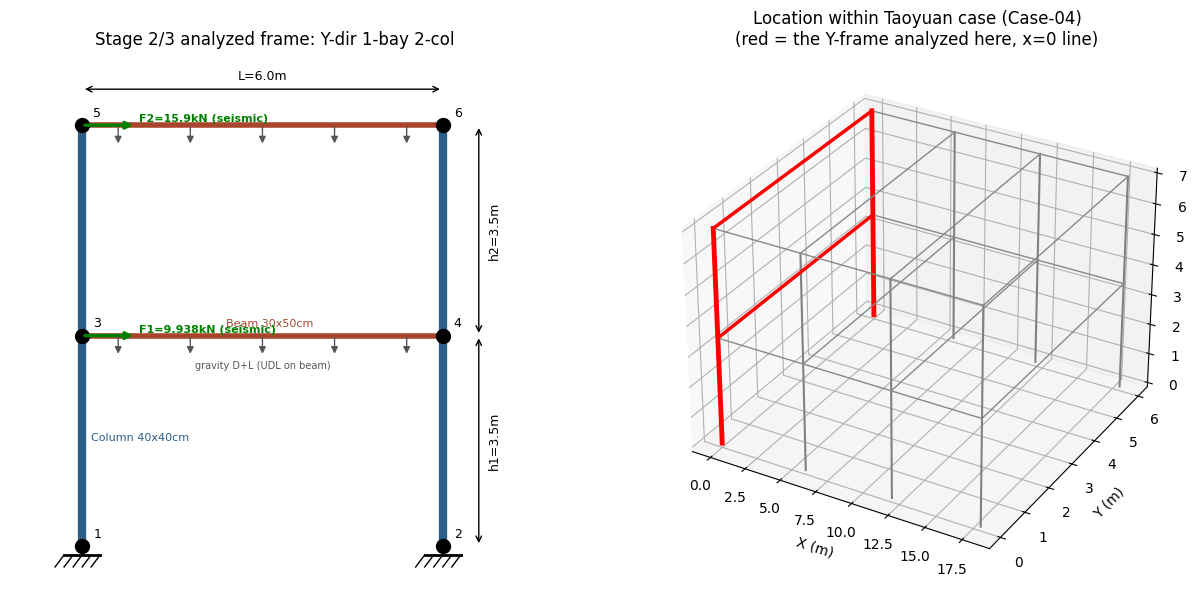

D_udl=23.830 kN/m, L_udl=13.239 kN/m (跟Stage3一致)
六組合跑完, 48 筆記錄
=== 1F柱組 Design Loop ===
  試 rho=0.01: worst utilization=33.7% (combo=C5, col1F_L-i端) -> PASS
>> 收斂: rho=0.01

=== 2F柱組 Design Loop ===
  試 rho=0.01: worst utilization=116.6% (combo=C1, col2F_R-j端) -> FAIL
  試 rho=0.015: worst utilization=68.9% (combo=C1, col2F_R-j端) -> PASS
>> 收斂: rho=0.015


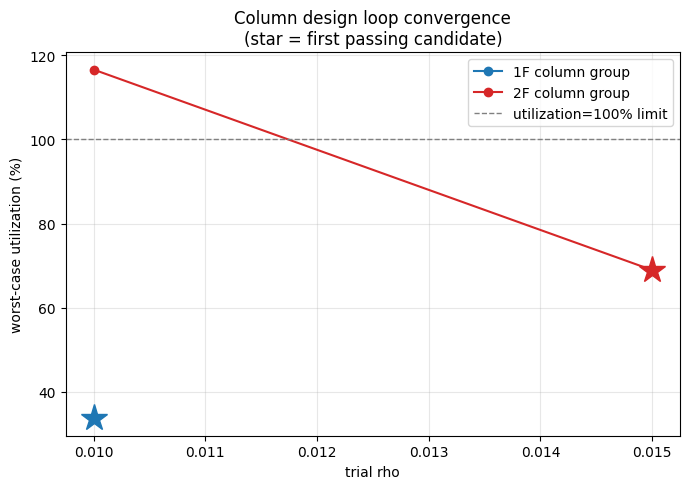

=== 1F beam ===
Mu(-)=157.09kN-m Mu(+)=94.32kN-m Vu=167.61kN
  TOP:    4-#6(D19), phiMn=171.75, 利用率=91.5%
  BOTTOM: 2-#7(D22), phiMn=119.17, 利用率=79.2%
  STIRRUP: #4(D13) @ 20cm

=== Roof beam ===
Mu(-)=142.13kN-m Mu(+)=109.28kN-m Vu=167.61kN
  TOP:    5-#5(D16), phiMn=150.48, 利用率=94.5%
  BOTTOM: 2-#7(D22), phiMn=119.17, 利用率=91.7%
  STIRRUP: #4(D13) @ 20cm

構件          配筋                           utilization
------------------------------------------------------
1F beam TOP 4-#6(D19)                       91.5%
1F beam BOT 2-#7(D22)                       79.2%
RF beam TOP 5-#5(D16)                       94.5%
RF beam BOT 2-#7(D22)                       91.7%
1F column   rho=0.01 (3+2+3 layout)           33.7%
2F column   rho=0.015 (3+2+3 layout)          68.9%

[PASS] 所有構件在Design Loop收斂的配筋下, 全部6組合的governing demand都在容量內


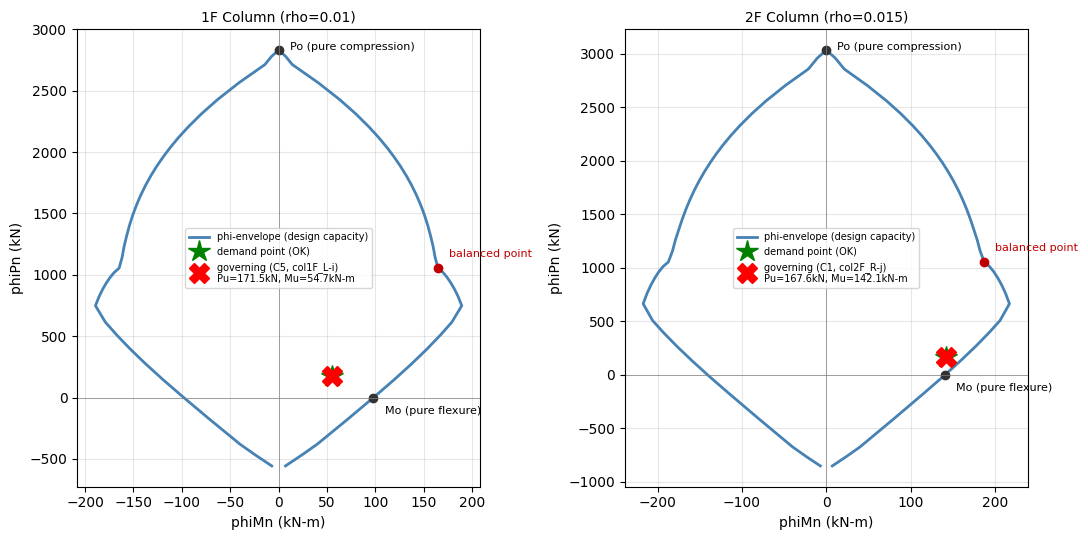

官方Stage 3/4重新執行完成
1F柱: rho=0.01, Pu=171.52, Mu=54.71
2F柱: rho=0.015, Pu=167.61, Mu=142.13


In [3]:

# 執行Stage3前15格(到demand extraction+分組為止, 不含Stage3自己的
# "Stage 4預覽"那幾格) + Stage4全部code cells, 在同一個namespace執行。
# exec()是純Python環境, 不認得Jupyter的"!"shell magic語法——先手動
# 把必要模組匯入exec_globals, 再逐行過濾掉"!"開頭的語句(不是整格跳過,
# 避免連同一格裡真正需要的import也被捨棄)
import openseespy.opensees as ops
import numpy as np
from rc_design import design_rebar, design_column_PM, design_stirrups

exec_globals = {'ops': ops, 'np': np, 'design_rebar': design_rebar,
                 'design_column_PM': design_column_PM, 'design_stirrups': design_stirrups}

def exec_cell_filtered(source, g):
    filtered_lines = [line for line in source.split(chr(10)) if not (line.strip().startswith('!') or line.strip().startswith('%'))]
    exec(chr(10).join(filtered_lines), g)

for c in nb3.cells[:15]:
    if c.cell_type == 'code':
        exec_cell_filtered(c.source, exec_globals)
for c in nb4.cells:
    if c.cell_type == 'code':
        exec_cell_filtered(c.source, exec_globals)

print("官方Stage 3/4重新執行完成")
print(f"1F柱: rho={exec_globals['rho_1F']}, Pu={exec_globals['worst_1F'][4]:.2f}, Mu={exec_globals['worst_1F'][5]:.2f}")
print(f"2F柱: rho={exec_globals['rho_2F']}, Pu={exec_globals['worst_2F'][4]:.2f}, Mu={exec_globals['worst_2F'][5]:.2f}")


## 萃取需要的官方資料,組裝成 `Stage 5` 檢核(重新執行,跟 `stage5_seismic_checks.ipynb` 同一套邏輯)

In [4]:

g = exec_globals
L, h1, h2, h_col, b_beam, h_beam = g['L'], g['h1'], g['h2'], g['h_col'], g['b_beam'], g['h_beam']
fc, fy = 280.0, 4200.0

col_1F = dict(Pu=round(g['worst_1F'][4],2), Mu=round(g['worst_1F'][5],2),
              combo=g['worst_1F'][1], rho=g['rho_1F'],
              Mn=round(g['worst_1F'][6]['matched_point']['Mn'],2),
              phiMn=round(g['worst_1F'][6]['matched_point']['phiMn'],2))
col_2F = dict(Pu=round(g['worst_2F'][4],2), Mu=round(g['worst_2F'][5],2),
              combo=g['worst_2F'][1], rho=g['rho_2F'],
              Mn=round(g['worst_2F'][6]['matched_point']['Mn'],2),
              phiMn=round(g['worst_2F'][6]['matched_point']['phiMn'],2))

beam_1F = dict(Mu_neg=round(g['d_1F']['Mu_neg'],2), Mu_pos=round(g['d_1F']['Mu_pos'],2),
               Vu=round(g['d_1F']['Vu'],2),
               As_top=round(g['d_1F']['top']['As_provided'],2), top_bar=f"{g['d_1F']['top']['n_bars']}-{g['d_1F']['top']['bar_size']}",
               As_bot=round(g['d_1F']['bot']['As_provided'],2), bot_bar=f"{g['d_1F']['bot']['n_bars']}-{g['d_1F']['bot']['bar_size']}",
               d=round(g['d_1F']['top']['d'],2),
               phiMn_top=round(g['d_1F']['top']['phiMn_provided'],2), phiMn_bot=round(g['d_1F']['bot']['phiMn_provided'],2))
beam_RF = dict(Mu_neg=round(g['d_RF']['Mu_neg'],2), Mu_pos=round(g['d_RF']['Mu_pos'],2),
               Vu=round(g['d_RF']['Vu'],2),
               As_top=round(g['d_RF']['top']['As_provided'],2), top_bar=f"{g['d_RF']['top']['n_bars']}-{g['d_RF']['top']['bar_size']}",
               As_bot=round(g['d_RF']['bot']['As_provided'],2), bot_bar=f"{g['d_RF']['bot']['n_bars']}-{g['d_RF']['bot']['bar_size']}",
               d=round(g['d_RF']['top']['d'],2),
               phiMn_top=round(g['d_RF']['top']['phiMn_provided'],2), phiMn_bot=round(g['d_RF']['bot']['phiMn_provided'],2))

print(f"1F柱: {col_1F}")
print(f"2F柱: {col_2F}")
print(f"1F樑: {beam_1F}")
print(f"屋頂樑: {beam_RF}")


1F柱: {'Pu': 171.52, 'Mu': 54.71, 'combo': 'C5', 'rho': 0.01, 'Mn': 185.53, 'phiMn': 166.98}
2F柱: {'Pu': 167.61, 'Mu': 142.13, 'combo': 'C1', 'rho': 0.015, 'Mn': 196.82, 'phiMn': 177.14}
1F樑: {'Mu_neg': 157.09, 'Mu_pos': 94.32, 'Vu': 167.61, 'As_top': 11.46, 'top_bar': '4-#6(D19)', 'As_bot': 7.74, 'bot_bar': '2-#7(D22)', 'd': 43.8, 'phiMn_top': 171.75, 'phiMn_bot': 119.17}
屋頂樑: {'Mu_neg': 142.13, 'Mu_pos': 109.28, 'Vu': 167.61, 'As_top': 9.93, 'top_bar': '5-#5(D16)', 'As_bot': 7.74, 'bot_bar': '2-#7(D22)', 'd': 43.8, 'phiMn_top': 150.48, 'phiMn_bot': 119.17}


In [5]:

def compute_Mpr(As_cm2, b_cm, d_cm, fc=280.0, fy=4200.0):
    fy_pr = 1.25*fy
    a = As_cm2*fy_pr/(0.85*fc*b_cm)
    return (As_cm2*fy_pr*(d_cm - a/2)) * 9.80665e-5

def Mn_at_Pu_matched(curve, Pu_target):
    sc = sorted(curve, key=lambda p: p['Pn'])
    for i in range(len(sc)-1):
        if sc[i]['Pn'] <= Pu_target <= sc[i+1]['Pn']:
            t = (Pu_target-sc[i]['Pn'])/(sc[i+1]['Pn']-sc[i]['Pn'])
            return sc[i]['Mn'] + t*(sc[i+1]['Mn']-sc[i]['Mn'])
    return None

def design_column_confinement(h_col_cm, Ln_cm, db_long_cm, fc=280.0, fyt=4200.0, cover_cm=4.0):
    lo = max(h_col_cm, Ln_cm/6, 45.0)
    bc = h_col_cm - 2*cover_cm
    so = min(max(10.0 + (35.0-bc)/3.0, 10.0), 15.0)
    s_max = min(h_col_cm/4, 6*db_long_cm, so)
    Ag = h_col_cm**2
    Ach = bc**2
    Ash_over_s_req = max(0.3*bc*(fc/fyt)*(Ag/Ach-1), 0.09*bc*fc/fyt)
    return dict(lo=lo, s_max=s_max, s_final=min((2*0.7133)/Ash_over_s_req, s_max))

def beam_stirrup_spacing(V_design, d_beam, db_long=1.9):
    Vn_req = V_design/0.75
    Vs_req_kgf = Vn_req/9.80665e-3
    s_from_Vs = (2*0.7133*4200.0*d_beam)/Vs_req_kgf
    s_max_seismic = min(d_beam/4, 6*db_long, 15.0)
    return min(s_from_Vs, s_max_seismic)

def joint_shear_check(As_top, Mpr_beam, h_avg, h_col_cm):
    T1_kN = (As_top*5250.0)*9.80665e-3
    Vcol_kN = Mpr_beam/h_avg
    Vj_kN = T1_kN - Vcol_kN
    fc_psi = fc*14.223
    Aj_in2 = (h_col_cm*h_col_cm)/6.4516
    Vn_kN = (10*(fc_psi**0.5)*Aj_in2/1000)*4.448
    phiVn_kN = 0.85*Vn_kN
    return dict(Vj_kN=round(Vj_kN,2), phiVn_kN=round(phiVn_kN,2), ratio=round(phiVn_kN/Vj_kN,2))

# SCWB
Mn_1F_beam_neg = beam_1F['phiMn_top']/0.9
sum_Mnc_1F = col_1F['Mn'] + col_2F['Mn']
scwb_1F_ratio = round(sum_Mnc_1F/Mn_1F_beam_neg, 2)
limit_exempt = round((h_col*100*h_col*100*fc/10)*9.80665e-3, 2)
roof_exempt = col_2F['Pu'] < limit_exempt

# 正負彎矩
ratio_posneg_1F = round((beam_1F['phiMn_bot']/0.9)/(beam_1F['phiMn_top']/0.9), 3)
ratio_posneg_RF = round((beam_RF['phiMn_bot']/0.9)/(beam_RF['phiMn_top']/0.9), 3)

# 梁capacity-design shear + 箍筋(用max(Vu,Ve_hinge))
Ln_beam = L - h_col
beam_shear = {}
for label, beam in [('1F_beam', beam_1F), ('roof_beam', beam_RF)]:
    Mpr_top = compute_Mpr(beam['As_top'], b_beam*100, beam['d'])
    Mpr_bot = compute_Mpr(beam['As_bot'], b_beam*100, beam['d'])
    Ve_hinge = (Mpr_top + Mpr_bot)/Ln_beam
    V_design = max(Ve_hinge, beam['Vu'])
    governing_V = "Ve_hinge" if Ve_hinge >= beam['Vu'] else "Vu_elastic"
    s = beam_stirrup_spacing(V_design, beam['d'])
    beam_shear[label] = dict(Mpr_top=round(Mpr_top,2), Mpr_bot=round(Mpr_bot,2),
                               Ve_hinge=round(Ve_hinge,2), V_design=round(V_design,2),
                               governing_shear_source=governing_V, stirrup_spacing_cm=round(s,2))

# 柱圍束
conf_1F = design_column_confinement(h_col*100, (h1-h_beam)*100, 1.6)
conf_2F = design_column_confinement(h_col*100, (h2-h_beam)*100, 1.8)

# 柱capacity-design shear
fy_pr_col = 1.25*fy
col_shear = {}
for label, col, Mpr_beam_adj, Ln_m in [
    ('1F_column', col_1F, beam_shear['1F_beam']['Mpr_top'], h1-h_beam),
    ('2F_column', col_2F, beam_shear['roof_beam']['Mpr_top'], h2-h_beam),
]:
    As_bar = col['rho']*h_col*100*h_col*100/8
    As_layers = [3*As_bar, 2*As_bar, 3*As_bar]
    r_pr = design_column_PM(b_cm=h_col*100, h_cm=h_col*100, As_per_layer_cm2=As_layers,
                              cover_to_center_cm=4.0, n_layers=3,
                              fc=fc, fy=fy_pr_col, Es=2.0e6, Pu_kN=col['Pu'], Mu_kNm=1.0)
    Mpr_col = Mn_at_Pu_matched(r_pr['curve'], col['Pu'])
    Ve_own = 2*Mpr_col/Ln_m
    Ve_beam = Mpr_beam_adj/Ln_m
    col_shear[label] = round(min(Ve_own, Ve_beam), 2)

# 接頭剪力
j1 = joint_shear_check(beam_1F['As_top'], beam_shear['1F_beam']['Mpr_top'], (h1+h2)/2, h_col*100)
j2 = joint_shear_check(beam_RF['As_top'], beam_shear['roof_beam']['Mpr_top'], h2, h_col*100)

print(f"SCWB 1F接頭: ratio={scwb_1F_ratio}")
print(f"屋頂接頭豁免: {roof_exempt}")
print(f"正負彎矩: 1F={ratio_posneg_1F}, 屋頂={ratio_posneg_RF}")
print(f"梁剪力: {beam_shear}")
print(f"柱圍束: 1F={conf_1F}, 2F={conf_2F}")
print(f"柱capacity-design shear: {col_shear}")
print(f"接頭剪力: 1F={j1}, 屋頂={j2}")


SCWB 1F接頭: ratio=2.0
屋頂接頭豁免: True
正負彎矩: 1F=0.694, 屋頂=0.792
梁剪力: {'1F_beam': {'Mpr_top': 233.57, 'Mpr_bot': 163.2, 'Ve_hinge': 70.85, 'V_design': 167.61, 'governing_shear_source': 'Vu_elastic', 'stirrup_spacing_cm': 10.95}, 'roof_beam': {'Mpr_top': 205.26, 'Mpr_bot': 163.2, 'Ve_hinge': 65.8, 'V_design': 167.61, 'governing_shear_source': 'Vu_elastic', 'stirrup_spacing_cm': 10.95}}
柱圍束: 1F={'lo': 50.0, 's_max': 9.600000000000001, 's_final': 3.962777777777778}, 2F={'lo': 50.0, 's_max': 10.0, 's_final': 3.962777777777778}
柱capacity-design shear: {'1F_column': 77.86, '2F_column': 68.42}
接頭剪力: 1F={'Vj_kN': 523.28, 'phiVn_kN': 591.71, 'ratio': 1.13}, 屋頂={'Vj_kN': 452.6, 'phiVn_kN': 591.71, 'ratio': 1.31}


## 組裝 `design_freeze.json`(`v3`,正式版)

In [6]:

design_freeze_v3 = {
    "status": "FROZEN",
    "version": 3,
    "supersedes": "v1, v2 (both DEPRECATED: independently reconstructed demand without knowledge of official Stage 2/3/4 pipeline, 1F column axial load off by ~80% vs official value)",
    "source_repo": "taiwan-seismic-code-calc",
    "source_notebooks": ["stage3_load_combinations_demand_extraction.ipynb (VL-16)",
                           "stage4_rc_design_loop.ipynb", "stage5_seismic_checks.ipynb"],
    "change_log": "v3重新執行官方stage3/stage4的真實結果(真實從屬寬度4.5m算出的D_udl=23.83/L_udl=13.24kN/m, 正式Design Loop每候選檢查全部6組合x兩端), 取代v1/v2用反推估計載重獨立重建的版本",
    "geometry": {"L_bay_m": L, "h1_m": h1, "h2_m": h2,
                  "col_section_cm": "40x40", "beam_section_cm": "30x50"},
    "materials": {"fc_kgf_cm2": fc, "fy_kgf_cm2": fy,
                   "stiffness_reduction": "beam 0.35Ig, column 0.7Ig"},
    "demands": {
        "1F_column": {"Pu_kN": col_1F['Pu'], "Mu_kNm": col_1F['Mu'], "governing_combo": col_1F['combo']},
        "2F_column": {"Pu_kN": col_2F['Pu'], "Mu_kNm": col_2F['Mu'], "governing_combo": col_2F['combo']},
        "1F_beam": {"Mu_neg_kNm": beam_1F['Mu_neg'], "Mu_pos_kNm": beam_1F['Mu_pos'], "Vu_kN": beam_1F['Vu']},
        "roof_beam": {"Mu_neg_kNm": beam_RF['Mu_neg'], "Mu_pos_kNm": beam_RF['Mu_pos'], "Vu_kN": beam_RF['Vu']},
        "gravity_load": {"D_udl_kN_m": round(g['D_udl'],3), "L_udl_kN_m": round(g['L_udl'],3),
                           "note": "from real tributary width 4.5m + 結構計算書-基本款.md real unit weights, NOT v1/v2's back-calculated estimate"},
    },
    "members": {
        "1F_column": {"section_cm": "40x40", "rho": col_1F['rho'], "Mn_kNm": col_1F['Mn'],
                       "confinement": {"lo_cm": conf_1F['lo'], "tie_spacing_cm": round(conf_1F['s_final'],2)},
                       "capacity_design_shear_kN": col_shear['1F_column']},
        "2F_column": {"section_cm": "40x40", "rho": col_2F['rho'], "Mn_kNm": col_2F['Mn'],
                       "governing_factor": "strength demand (requires higher rho than 1F per official Design Loop)",
                       "confinement": {"lo_cm": conf_2F['lo'], "tie_spacing_cm": round(conf_2F['s_final'],2)},
                       "capacity_design_shear_kN": col_shear['2F_column']},
        "1F_beam": {"section_cm": "30x50", "top_As_cm2": beam_1F['As_top'], "top_bar": beam_1F['top_bar'],
                     "bottom_As_cm2": beam_1F['As_bot'], "bottom_bar": beam_1F['bot_bar'],
                     "posneg_ratio": ratio_posneg_1F,
                     "Mpr_top_kNm": beam_shear['1F_beam']['Mpr_top'], "Mpr_bottom_kNm": beam_shear['1F_beam']['Mpr_bot'],
                     "shear_governing_source": beam_shear['1F_beam']['governing_shear_source'],
                     "shear_design_kN": beam_shear['1F_beam']['V_design'],
                     "stirrup_spacing_hinge_zone_cm": beam_shear['1F_beam']['stirrup_spacing_cm'],
                     "note": "Ve_hinge < Vu_elastic in this case (real gravity load is substantial) -- elastic demand governs shear design, not capacity-design shear. Both must be checked, max() taken."},
        "roof_beam": {"section_cm": "30x50", "top_As_cm2": beam_RF['As_top'], "top_bar": beam_RF['top_bar'],
                       "bottom_As_cm2": beam_RF['As_bot'], "bottom_bar": beam_RF['bot_bar'],
                       "posneg_ratio": ratio_posneg_RF,
                       "Mpr_top_kNm": beam_shear['roof_beam']['Mpr_top'], "Mpr_bottom_kNm": beam_shear['roof_beam']['Mpr_bot'],
                       "shear_governing_source": beam_shear['roof_beam']['governing_shear_source'],
                       "shear_design_kN": beam_shear['roof_beam']['V_design'],
                       "stirrup_spacing_hinge_zone_cm": beam_shear['roof_beam']['stirrup_spacing_cm']},
    },
    "scwb": {
        "1F_joint": {"sum_Mnc_kNm": round(sum_Mnc_1F,2), "ratio": scwb_1F_ratio,
                      "status": "PASS" if scwb_1F_ratio>=1.2 else "FAIL", "code_ref": "ACI 318-19 18.7.3.1"},
        "roof_joint": {"status": "EXEMPT", "reason": "column discontinuous above + Pu<Ag*fc'/10",
                        "code_ref": "ACI 318-19 18.7.3.1 exception"},
    },
    "joint_shear": {"1F_joint": j1, "roof_joint": j2},
    "assumptions": [
        "Stage 2/3 canonical elastic model: 單榀2D substructure, 樓板內力分配(多榀構架之間)不在這個模型求解範圍內",
        "重力載重: D_udl/L_udl來自真實從屬寬度(4.5m)+結構計算書-基本款.md真實單位重量, 不是反推估計值",
        "有效勁度折減(0.35Ig/0.7Ig)是這個分析目的下宣告的建模假設, 不是唯一或絕對正確的RC真實勁度",
        "柱斷面(40x40cm)、梁斷面(30x50cm)是Case-03.5工程師手動選定的初步試設尺寸",
        "未涵蓋範圍(不在這次凍結內): 錨定/搭接長度、柱主筋沿全長排筋細節、接頭橫向鋼筋排列細節、X向3跨4柱/完整8柱3D模型",
        "重要發現: 梁capacity-design shear(Ve_hinge)在這個真實重力載重量級下, 反而小於Stage 4彈性需求剪力(Vu, 來自1.4D+1.7L等組合)——剪力設計必須取max(Vu, Ve_hinge), 不能只看capacity-design shear",
        "v1/v2已棄用, 原因: 兩者都用反推估計的重力載重(49.2kN/m), 跟官方真實值(D+L=37.07kN/m)相差24.7%, 1F柱軸力相差近80%",
    ],
    "code_references": ["ACI 318-19 Chapter 18 (Special moment frames)", "ACI 318-19 22.4 (PM interaction)",
                          "ACI 318-19 18.7.3.1 (roof joint exemption, verified via web search)"],
}

with open('design_freeze.json', 'w', encoding='utf-8') as f:
    json.dump(design_freeze_v3, f, indent=2, ensure_ascii=False)
print("design_freeze.json(v3) 產生完成")


design_freeze.json(v3) 產生完成


## 驗證:跟 `stage5_seismic_checks.ipynb` 逐項比對

In [7]:

checks = [
    (col_1F['Mn'], 185.53, "1F柱Mn"),
    (col_2F['Mn'], 196.82, "2F柱Mn"),
    (sum_Mnc_1F, 382.35, "1F接頭sum(Mnc)"),
    (scwb_1F_ratio, 2.00, "1F接頭SCWB比值"),
    (j1['Vj_kN'], 523.28, "1F接頭Vj"),
    (conf_1F['s_final'], 3.96, "1F柱圍束間距"),
]
all_pass = True
for computed, reference, label in checks:
    diff = abs(computed-reference)
    ok = diff < max(0.5, abs(reference)*0.02)
    all_pass = all_pass and ok
    print(f"{label}: 重新計算={computed}, 原notebook={reference}, 差異={diff:.4f} {'OK' if ok else 'MISMATCH'}")

assert all_pass
print("\n[PASS] design_freeze.json(v3)跟stage5_seismic_checks.ipynb一致")


1F柱Mn: 重新計算=185.53, 原notebook=185.53, 差異=0.0000 OK
2F柱Mn: 重新計算=196.82, 原notebook=196.82, 差異=0.0000 OK
1F接頭sum(Mnc): 重新計算=382.35, 原notebook=382.35, 差異=0.0000 OK
1F接頭SCWB比值: 重新計算=2.0, 原notebook=2.0, 差異=0.0000 OK
1F接頭Vj: 重新計算=523.28, 原notebook=523.28, 差異=0.0000 OK
1F柱圍束間距: 重新計算=3.962777777777778, 原notebook=3.96, 差異=0.0028 OK

[PASS] design_freeze.json(v3)跟stage5_seismic_checks.ipynb一致
